# Chapter1.Evaluation with LLM

LLM의 활용 가능성은 정말 무궁무진합니다. 

단순히 어떤 질의에 대해 대답하는 것만을 넘어서, 이번에는 다양한 통계적인 방법에 LLM을 접목시키기 위하여 LLM을 사용한 분석을 진행하고, 이를 통해 인사이트
를 얻는 전체적인 과정을 살펴보도록 하겠습니다.


가장 먼저 만나게 될 주제는 LLM을 활용하여 주관적인 영역을 평가하는 것입니다.

방법론 자체에 의문이 있을 수 있으나, 해당 방법은 인간과의 상관관계를 어느정도 입증받은 방법으로, 다양한 창조적이고 주관적인 평가에 사용되고 있습니다

# 문제0. 
llm이라는 이름의 python=3.10 가상환경을 생성하고 pandas,numpy,openai,tqdm,scipy, matplotlib,seaborn,json,dotenv 패키지를 설치해주세요.

# 문제1. 
LLM의 프롬프트 엔지니어링 방법 중 ChainofThoughts(CoT) 기법에 대하여 자세하게 설명해주세요.

> NLP 분야에서 모델의 성능 향상을 위해 사이즈를 키우는 방법은 지속적으로 제시되어왔으나, 이는 추론 분야에서 높은 성능 향상을 가져오지는 못했다.
> 
> COT는 LLM의 산술 문제나 상식을 추론하는 능력을 크게 향상 시킨 기법으로 'Chain-of-Thought Prompting Elicits Reasoning in Large Language Models' 에서 최초로 LLM에 도입하였다. A series of intermediate reasoning steps 를 통하여 추론 능력을 향상 시키는데 최종 답으로 다가가는 과정에서 LLM이 잘못된 추론을 내렸을 경우 어디서 틀렸는지 디버깅이 가능하고, 어떤 이유로 LLM이 그러한 답을 제시했는지 논리적이고 가시적으로 보여준다. 위 논문에서는 세가지 LLM으로 Experiment를 진행하였으며 Prompting 만을 통해 추론 능력을 키울 수 있었다. chain-of-thought 형식의 prompt를 few-shot으로 제공함으로써 LLM이 최종 결과를 생성할 때 필요한 중간 과정 및 추론 과정을 모델 스스로 생성할 수 있게 한다.

문제2.

NLGEvaluationusingGPT-4withBetterHumanAlignment (EMNLP2023)의 G-Eval에 대하여 자세하게 설명해주세요.
- (HINT) GPT-4 기준으로 설명하시면 됩니다.GPT-3.5의 방법에 대해서는 고려하지 않아도 됩니다.

> G-EVAL은 Prompting을 통해 평가자 LLM이 바로 평가 점수를 출력으로 생성하도록 유도한다.
> LLM 기반 Evaluator가 LLM이 생성한 text에 편향될 수 있는 문제를 해결하고 Human-Evaluation과 일치하는 평가 방법을 제공하기 위해 제안된 프레임워크이다.
> 크게 세가지 구성요소로 이루어지는데 Evaluation work의 정의와 Evalaution Criteria가 포함된 Prompt, LLM이 생성한 Intermediate Step으로 세부적인 평가 Step을 설명하는 CoT, LLM을 호출하고 반환된 토큰의 확률에 따라서 점수를 계산하는 Scoring Fucntion이다.
>
> Scoreing Function은 Prompt, auto CoT, input context, target text를 받아 LLM을 호출한다. return 값은 출력 토큰의 확률을 가중치로 사용한 출력 토큰들의 가중합이다. 

#### 문제3.
제공받은 api_key를 OPENAI_API_KEY라는 이름으로 .env 파일에 명시해주세요. 그 후, dot_env 패키지를 통해 api_key를 불러와 openai의 API_KEY에 입력해주세요.

- (HINT).env파일은 파일명이 .으로 시작되어 숨김처리된 파일입니다. 따라서 파일을 만든 후 보이지 않는다면, 이를 고려하여 주세요

In [1]:
from dotenv import load_dotenv
import os
import openai

print(openai.__version__)

load_dotenv()
API_KEY = os.getenv("OPENAI_API_KEY")

openai.api_key = API_KEY

1.55.0


## 문제 4

지금부터 우리가 만들어 나갈 모델은,  
**사회복지학과에서 상담 실습을 위한 상담 내용 채점 및 피드백 챗봇 모델**을 만들어 달라는 요청을 받았다는 가정하에 시작합니다.

### 요구 사항
1. `data.jsonl` 파일을 불러와 `input`, `output` 두 개의 컬럼이 존재하도록 **pandas 데이터프레임**으로 변환하세요.
2. **힌트**:  
   - `json.loads`를 사용해 데이터를 불러옵니다.
   - 데이터를 `pd.DataFrame`에 전달하면 빠르게 데이터프레임으로 변환할 수 있습니다.


In [2]:
import json
import pandas as pd

with open('data.jsonl', 'r') as file:
    data = [json.loads(line) for line in file]

df = pd.DataFrame(data)

display(df)

,input,output
0,"저 사실, 약간 중2병 같은 걸 증상을 보이고 있습니다.\n그래서 대학교를 가면서도...",사우님이 중2병적인 행동과 태도를 가지고 있다고 느껴져 스트레스를 받으시는 상황입니...
1,회사에서 일이 너무 바빠서 스트레스 받아요.\n회사에서 일이 너무 많아서 스트레스 ...,사우님이 회사에서 일이 너무 많아서 지쳐서 스트레스를 받고 있으시다는데요. 하루종일...
2,남들에게 이상해보인다는 생각 때문에 항상 불안하고 스트레스 받아요. 눈치보지 말라고...,사우님 남들에게 이상하게 보일까봐 불안하고 스트레스 받으시네요. 눈치보지 말라고 해...
3,요즘 회사에서 일이 많아지면서 나 혼자 다 이뤄내야 한다는 압박감이 들어요. 이전에...,사우님은 회사에서 일이 많아져서 혼자 다 처리해야 하는 압박감 때문에 불안감을 느끼...
4,"저는 요즘 일이 많아지면서 체력적으로도, 정신적으로도 지치게 됐어요. 마감기한이 얼...","사우님 요즘 일이 많아지면서 체력적으로도, 정신적으로도 지친 상태이고 일 할 때마다..."
...,...,...
13229,남자친구가 집에 안와요.\n저랑 2년째 연애 중인 남자친구가 집에 안와요. 평소에 ...,사우님 남자친구가 집에 안와서 연락도 안되고 메시지도 안읽혀요. SNS에서는 다른 ...
13230,요즘 연락이 잘 안와서 혼자 있는 시간이 많은데 자꾸 불안하고 스트레스를 받는 느낌...,"사우님, 요즘 자주 혼자시간이 많아져 불안하고 스트레스를 많이 받으시는 것 같아요...."
13231,저 이제 입사한지 3년 됐는데 연봉이나 직급이 하나도 안올라갔어요. 그리고 동기들은...,사우님은 이제 입사한지 3년이 되었는데 직급이나 연봉이 올라가지 않았습니다. 게다가...
13232,최근에 난감한 상황에 처해 있습니다. 제가 일하는 회사에서 동료들과 대립하고 있습니...,사우님은 현재 일하는 회사에서 동료들과 대립하고 있어 힘든 상황입니다. 팀원들과 생...


## 문제 5
- 실제 분석이라면 전체 데이터를 모두 사용했겠지만, 주제 분석이므로 **200개의 데이터**만 사용하기로 합니다.
- **Random sampling**을 통해 **100개의 데이터프레임**을 생성하고, 이를 `random_sample`이라는 이름으로 저장하세요.

### 힌트
- `df.sample`을 사용하면 쉽게 샘플링을 진행할 수 있습니다.

In [3]:
# random sample 100 rows
random_sample = df.sample(n=100, random_state=42)
random_sample.reset_index(drop=True, inplace=True)
display(random_sample.head())

,input,output
0,내가 가지고 있는 인맥들 중에 내 생각을 이해하고 도와주는 사람이 너무 없어요. 다...,"사우님의 이야기를 들어보니, 사우님이 가지고 있는 인맥들이 내 생각을 이해하고 도와..."
1,요즘은 집에 있는 것보다 회사에서 일하고 있는게 더 편하고 쉽게 느껴져요. 집에 있...,"사우님은 요즘 회사에서 일하고 있는 것이 더 편하고 쉽게 느껴진다고 하셨는데, 집에..."
2,부모님이 고민이 많아요.\n요즘 부모님이 마음이 복잡해보여요. 요즘들어 매일 걱정하...,사우님 부모님께서는 대학교를 가면 생활비 문제와 대학교에서 제가 어떻게 지낼지 걱정...
3,회사에서 제가 하는 업무가 너무 어렵고 벅차고 복잡합니다. 제가 효율적으로 일을 할...,사우님의 업무는 너무 어려워 벅차고 복잡해져서 효율적으로 일을 할 방법을 찾고 있어...
4,최근 일이 잘 안 풀리고 지치는 기분이에요.\n평소에는 매우 활발하고 에너지가 넘치...,"사우님 최근 일이 잘 안풀리면서 피로감, 우울감, 스트레스를 느끼고 계신가요? 평소..."


## 문제 6
- 단순히 **API를 호출할 수 있는 `simple_llm` 함수**를 만들어 주세요.

### 조건
1. **모델**: `'gpt-4o-mini'` 모델만 사용해야 합니다.  
   - 기타 모델 사용 시 API가 차단될 수 있습니다.
2. **temperature 설정**: `temperature=0.3`으로 설정하세요.  
   - **설명**: `temperature`가 어떤 역할을 하는지 짧게 작성해 주세요.
3. **Input**: 프롬프트(`input_query`)를 입력값으로 설정하세요.
4. **Output**: 함수는 **response 객체가 아닌 실제 response text**만 반환하도록 설계하세요.

In [75]:
def simple_llm(input_query):
    '''        
    ### 조건
    1. **모델**: `'gpt-4o-mini'` 모델만 사용해야 합니다.  
    - 기타 모델 사용 시 API가 차단될 수 있습니다.
    2. **temperature 설정**: `temperature=0.3`으로 설정하세요.  
    - **설명**: `temperature`는 생성된 응답의 창의성과 다양성을 제어합니다. 낮은 값일수록 더 결정론적인 응답을 생성합니다.
    3. **Input**: 프롬프트(`input_query`)를 입력값으로 설정하세요.
    4. **Output**: 함수는 **response 객체가 아닌 실제 response text**만 반환하도록 설계하세요.
    '''

    client = openai.Client()

    response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You are a psychology expert evaluating counselor empathy."},
                    {"role": "user", "content": input_query}
                ],
                temperature=0.3, 
            )
    return response.choices[0].message.content.strip()



## 문제 7
### G-eval 구현
- **G_eval_for_empathy** 함수를 작성하세요.

### 조건
1. **모델 매개변수 설정**:
   - `temperature=1`
   - `max_tokens=4`
   - `top_p=1`
   - `frequency_penalty=0`
   - `presence_penalty=0`
   - `n=20`
2. **평가 기준**:
   - G-eval을 위해 **empathy 점수에 대한 평가 기준**을 작성하세요.
   - 아래 내용을 바탕으로 본인의 임의대로 작성합니다.

## G-eval Prompt Format for Empathy

"You will be provided with a transcript of a dialogue between a counselor and a patient.  
Your task is to evaluate the counselor's level of empathy in the conversation."

### **Purpose of Evaluation**  
- **!--직접 작성하여 주세요--!**

### **Evaluation Process**  
1. **Read the Transcript Thoroughly**  
   - **!--직접 작성하여 주세요--!**
2. **Analyze the Counselor’s Responses**  
   - **!--직접 작성하여 주세요--!**
3. **Assign a Score**  
   - **!--직접 작성하여 주세요--!**  
   - 평가 기준: **5점 척도**로 평가합니다.

### **Assumptions**  
- The evaluator is a psychology graduate student familiar with counseling  techniques and theories.
- The evaluator should use their academic understanding of empathy 
to provide a balanced and context-sensitive assessment.

---

### Input
- **Transcript**: `{transcript}`

### Output
One %2f score only. Never include additional comments or explanations with the 
score. Do not use simple integers; instead, ensure a nuanced and rigorous evaluation using 
decimal values that match the appropriate level of precision. Then write a reason below.




## 문제 7-3
- 출력된 `response` 객체에서 **text**만을 추출하세요.
- 추출한 **20개의 text**를 `float`로 변환한 후, 평균을 계산하여 상담 진행 내용의 **상담사 공감 점수**를 반환하세요.

---



## 문제 7-4
- **temperature=1**로 설정했으므로, `float`로 변환되지 않는 응답이 포함될 가능성이 있습니다.
- 이를 처리하기 위해:
  1. **`while`문**과 **`try-except`문**을 적절히 활용하세요.
  2. 오류가 발생하면 재시도하고, 성공하면 다음 단계로 넘어가도록 코드를 작성하세요.

### 힌트
```python
while True:
    try:
        # 정상적으로 수행되면 break
        break
    except:
        # 오류 발생 시 다시 시도
        pass



In [7]:
import openai
import time

def G_eval_for_empathy(transcript):
    """
    Evaluates the counselor's empathy level for a given transcript using OpenAI API.
    Extracts scores from the response, calculates the average, and retries on error.
    """

   

    prompt = (
        f"You will be provided with a transcript of a dialogue between a counselor and a patient.\n"
        f"Your task is to evaluate the counselor's level of empathy in the conversation.\n\n"
        f"### Purpose of Evaluation\n"
        f"The goal is to assess how well the counselor demonstrates understanding, support, "
        f"and emotional connection with the patient.\n\n"
        f"### Evaluation Process\n"
        f"1. Review the Transcript:\n"
        f"   - Carefully read each patient statement and the corresponding counselor response.\n"
        f"   - Ensure that the counselor's response directly addresses the patient's specific concerns or emotions.\n"
        f"   - Consider whether the tone, language, and content of the counselor's response reflect active listening and understanding.\n\n"
        f"2. Analyze the Counselor's Responses:\n"
        f"   - Evaluate whether the counselor provides validation, support, or constructive feedback as needed.\n"
        f"   - Check if the counselor avoids dismissive or overly generic statements.\n"
        f"   - Look for signs of personalization in the counselor's response that indicate a genuine effort to connect.\n\n"
        f"3. Assign a Score:\n"
        f"   - Rate the counselor's empathy level for the transcript on a scale of 1 to 5.\n"
        f"   - Use decimal points to provide a nuanced evaluation (e.g., 3.7 or 4.2).\n"
        f"   - Ensure that the score reflects the overall depth and quality of the counselor's empathetic engagement.\n\n"
        f"### Assumptions\n"
        f"The evaluator is a psychology graduate student familiar with counseling techniques and theories.\n"
        f"- The evaluator should use their academic understanding of empathy to provide a balanced and context-sensitive assessment.\n\n"
        f"### Input\n"
        f"Transcript: {transcript}\n\n"
        f"### Output\n"
        f"Provide ONLY a single float score between 1 and 5 with up to two decimal places. Do not include any additional text."
    )
    client = openai.OpenAI()  # Initialize the client


    while True:
        try:
            # Use chat completions for GPT-4o-mini
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You are a psychology graduate student evaluating counselor empathy."},
                    {"role": "user", "content": prompt}
                ],
                temperature=1, 
                max_tokens=4,  
                n=20  # Number of completions to generate
            )

            texts = [choice.message.content.strip() for choice in response.choices]
            scores = []

            for text in texts:
                try:
                    score = float(text) 
                    if 1 <= score <= 5:
                        scores.append(score)
                except ValueError:
                    print(f"Invalid response skipped: {text}")

            if scores:
                avg_score = sum(scores) / len(scores)
                return {"average_score": avg_score, "scores": scores}

            else:
                raise ValueError("No valid scores extracted from response.")

        except Exception as e:
            print(f"Error occurred: {e}. Retrying...")
            time.sleep(2)  

# 문제8.
random_sample의 input,output에 대해 

transcript=f"input:{random_sample.loc[i,'input']} /n/noutput:{random_sample.loc[i,'output']}"로 지정해준 후,

G_eval_for_empathy모델을 모든 행에 대해 적용하여 emp_score라는 새로운 열로 각 점수를 저장하여주세요.

(조건) tqdm을 적용하여 iteration을 진행하는 데에 걸린 시간을 명시하여주세요.

In [8]:
# only one transcript
transcript = f"input: {random_sample['input'][0]}\noutput: {random_sample['output'][0]}"

G_eval_for_empathy(transcript)

{'average_score': 3.84,
 'scores': [4.2,
  4.2,
  3.8,
  3.5,
  3.8,
  3.8,
  3.5,
  3.8,
  3.8,
  4.0,
  3.5,
  4.2,
  4.5,
  4.2,
  3.8,
  3.6,
  3.8,
  3.5,
  3.8,
  3.5]}

In [12]:
from tqdm import tqdm

def calculate_empathy_scores(random_sample):
    random_sample['emp_score'] = None
    
    for i in tqdm(range(len(random_sample)), desc="Evaluating empathy scores"):
        transcript = f"input:{random_sample.loc[i,'input']}\n\noutput:{random_sample.loc[i,'output']}"
        emp_score = G_eval_for_empathy(transcript)
        random_sample.loc[i, 'emp_score'] = emp_score["average_score"]
    
    return random_sample

In [13]:
random_sample = calculate_empathy_scores(random_sample)

Evaluating empathy scores: 100%|██████████| 100/100 [02:39<00:00,  1.59s/it]


,input,output,emp_score,scores
0,내가 가지고 있는 인맥들 중에 내 생각을 이해하고 도와주는 사람이 너무 없어요. 다...,"사우님의 이야기를 들어보니, 사우님이 가지고 있는 인맥들이 내 생각을 이해하고 도와...",3.56,NaN
1,요즘은 집에 있는 것보다 회사에서 일하고 있는게 더 편하고 쉽게 느껴져요. 집에 있...,"사우님은 요즘 회사에서 일하고 있는 것이 더 편하고 쉽게 느껴진다고 하셨는데, 집에...",4.355,NaN
2,부모님이 고민이 많아요.\n요즘 부모님이 마음이 복잡해보여요. 요즘들어 매일 걱정하...,사우님 부모님께서는 대학교를 가면 생활비 문제와 대학교에서 제가 어떻게 지낼지 걱정...,4.3575,NaN
3,회사에서 제가 하는 업무가 너무 어렵고 벅차고 복잡합니다. 제가 효율적으로 일을 할...,사우님의 업무는 너무 어려워 벅차고 복잡해져서 효율적으로 일을 할 방법을 찾고 있어...,4.215,NaN
4,최근 일이 잘 안 풀리고 지치는 기분이에요.\n평소에는 매우 활발하고 에너지가 넘치...,"사우님 최근 일이 잘 안풀리면서 피로감, 우울감, 스트레스를 느끼고 계신가요? 평소...",4.19,NaN


In [1]:
# random_sample.to_csv('random_samplex_with_scores.csv', index=False)
import pandas as pd

random_sample = pd.read_csv('random_samplex_with_scores.csv')
display(random_sample.head())

,input,output,emp_score
0,내가 가지고 있는 인맥들 중에 내 생각을 이해하고 도와주는 사람이 너무 없어요. 다...,"사우님의 이야기를 들어보니, 사우님이 가지고 있는 인맥들이 내 생각을 이해하고 도와...",3.5600
1,요즘은 집에 있는 것보다 회사에서 일하고 있는게 더 편하고 쉽게 느껴져요. 집에 있...,"사우님은 요즘 회사에서 일하고 있는 것이 더 편하고 쉽게 느껴진다고 하셨는데, 집에...",4.3550
2,부모님이 고민이 많아요.\n요즘 부모님이 마음이 복잡해보여요. 요즘들어 매일 걱정하...,사우님 부모님께서는 대학교를 가면 생활비 문제와 대학교에서 제가 어떻게 지낼지 걱정...,4.3575
3,회사에서 제가 하는 업무가 너무 어렵고 벅차고 복잡합니다. 제가 효율적으로 일을 할...,사우님의 업무는 너무 어려워 벅차고 복잡해져서 효율적으로 일을 할 방법을 찾고 있어...,4.2150
4,최근 일이 잘 안 풀리고 지치는 기분이에요.\n평소에는 매우 활발하고 에너지가 넘치...,"사우님 최근 일이 잘 안풀리면서 피로감, 우울감, 스트레스를 느끼고 계신가요? 평소...",4.1900


# 문제9.
random_sample의 emp_score 열에 대한 kdeplot을 그려주세요.

(HINT) seaborn이나 scipy 둘 중 어떤 것을 사용하셔도 무방합니다.

<Axes: xlabel='emp_score', ylabel='Count'>

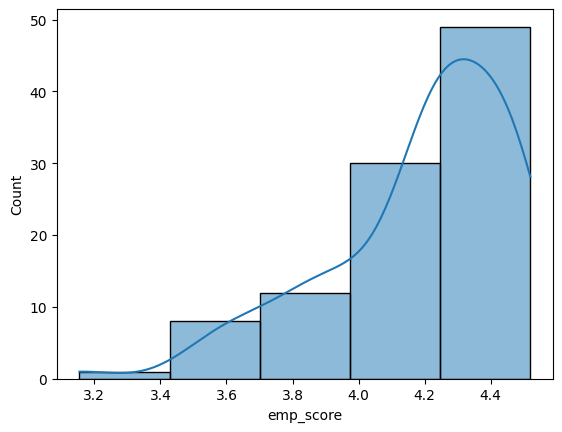

In [2]:
import seaborn as sns

sns.histplot(random_sample['emp_score'], bins=5, kde=True)

# (보너스문제 1, 2)

Quantile Transformation:
입력 데이터의 분포를 목표 분포(균일 분포 또는 정규 분포)로 변환하는 기법으로 Quantile을 보존하여 분포를 균일하게 Transformation 한다.

이상치의 영향을 줄이고 분포를 정규화하는데 효과적임.

<Axes: ylabel='Frequency'>

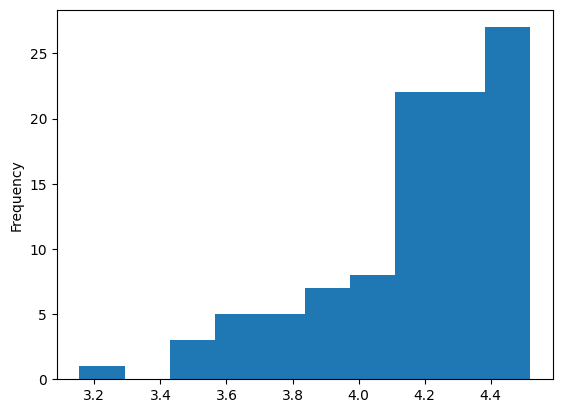

In [21]:
random_sample["emp_score"].plot(kind = "hist")

<Axes: xlabel='emp_score', ylabel='Count'>

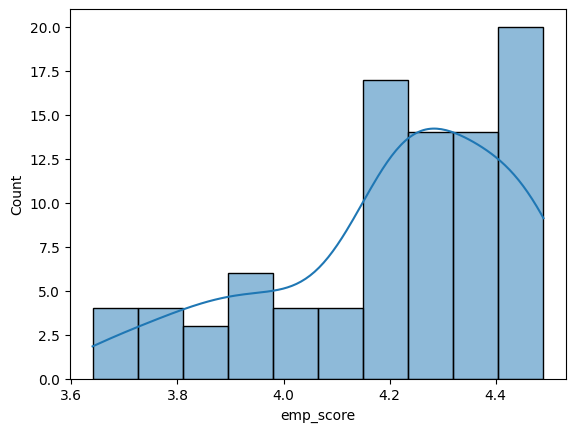

In [23]:
# Remove Outlier 

sns.histplot(random_sample['emp_score'], bins=10, kde=True)

In [26]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler

def normality_test_and_transformation(random_sample, ub = 0.98, lb=0.02):
    # Shapiro-Wilk Test for Original EMP Score
    print("Original EMP Score Shapiro-Wilk Test")
    statistic, p_value = stats.shapiro(random_sample['emp_score'].dropna())
    print(f"Statistic: {statistic}")
    print(f"P-value: {p_value}")
    
    alpha = 0.05
    if p_value > alpha:
        print("Do not reject H0")
    else:
        print("Reject H0 (not normal)")
    
    # Remove Outliers
    lb, ub = random_sample["emp_score"].quantile([lb, ub])
    filtered_data = random_sample[(random_sample["emp_score"] >= lb) & (random_sample["emp_score"] <= ub)]

    print(f"Length of Filtered Data: {len(filtered_data)}")

    # Quantile Transformation
    qt = QuantileTransformer(output_distribution='normal', n_quantiles=len(filtered_data))
    transformed_data = qt.fit_transform(filtered_data[['emp_score']])
    
    # Min-Max Scaling scale 5
    mm_scaler = MinMaxScaler(feature_range=(1, 5))
    scaled_data = mm_scaler.fit_transform(transformed_data)


    # Shapiro-Wilk Test for Original and Transformed EMP Score
    print("\nTransformed EMP Score Shapiro-Wilk Test")
    statistic, p_value = stats.shapiro(scaled_data)
    print(f"Statistic: {statistic}")
    print(f"P-value: {p_value}")
    
    if p_value > alpha:
        print("Do not reject H0 after transformation")
    else:
        print("Reject H0 after transformation (not normal)")

    print(f"Shape of Scaled Data: {scaled_data.shape}")
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(random_sample['emp_score'], kde=True)
    plt.title('Original Empathy Scores')
    plt.xlabel('Empathy Score')
    
    plt.subplot(1, 2, 2)
    sns.histplot(scaled_data, kde=True)
    plt.title('Transformed Empathy Scores')
    plt.xlabel('Transformed Empathy Score')
    
    plt.tight_layout()
    plt.show()
    
    # Q-Q Plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    stats.probplot(random_sample['emp_score'], dist="norm", plot=plt)
    plt.title('Q-Q Plot: Original Empathy Scores')

    plt.subplot(1, 2, 2)
    stats.probplot(scaled_data.flatten(), dist="norm", plot=plt)
    plt.title('Q-Q Plot: Transformed Empathy Scores')
    
    plt.tight_layout()
    plt.show()
    print(f"Lower Bound: {lb}")
    print(f"Upper Bound: {ub}")
    print(f"Length of Scaled Data: {len(scaled_data)}")

    
    # merge transformed data with original data
    result_df = random_sample.copy()
    result_df['transformed_emp_score'] = np.nan
    result_df.loc[filtered_data.index, 'transformed_emp_score'] = scaled_data
    
    return result_df

In [ ]:
result = normality_test_and_transformation(random_sample, ub=0.98, lb=0.02)
result.to_csv('random_sample_with_transformed_scores.csv', index=False)

# Chapter2.Prompt Engineering

여러분은 전문가가 없이도 LLM의 추론 능력과 객관성에 근거하여 주관적인 척도를 수치화할 수 있었습니다.

이제 이 점수를 근거로 LLM이 사용자를 적극적으로 피드백할 수 있도록 다양한 시도를 해볼 차례입니다!

## 문제 1: 
Few-shot Learning에 대해 자세하게 설명해주세요.


> 소수의 학습 데이터(예: 몇 개의 예시)만으로도 모델이 새로운 작업을 일반화할 수 있도록 훈련하는 기법으로
>
> 대량의 데이터를 주입하여 모델을 학습시키는 머신러닝 혹은 타 AI 모델의 학습 방식과는 대조적이다.
>
> 회귀에도 사용될 수 있으나 주로 분류 문제에서 다양하게 사용되고 있다.
>
> Few-shot Learning은 Meta Learning, Transfer Learning을 통해 수행될 수 있는데, 
> 
> Transfer Learning은  Pre-trained 모델을 중심으로 학습되며 Few-shot, 적은 수의 데이터로 모델의 재학습이 진행된다.
>
> Meta-Learning은 여러 Task 를 동시에 학습하며 각 Task 간의 차이 또한 학습된다.    
> 
> 전체 학습 이후 소량의 데이터(few-shot) 으로도 추론 할 수 있는 범용적인 모델 생성 된다.


## 문제 2: 하위 10%, 50%, 90% 점수 텍스트 저장

### 요구 사항
1. **열 추출**:
   - `random_sample`에서 `emp_score` 열을 기준으로 하위 10%, 50%, 90%에 해당하는 데이터를 추출하세요.

2. **텍스트 형식**:
   - 각 점수를 다음과 같은 형식으로 저장하세요:
     ```
     Example:[score:{random_sample.loc[i, 'emp_score']}, 
     input:{random_sample.loc[i, 'input']}, 
     output:{random_sample.loc[i, 'output']}]
     ```

3. **저장 변수**:
   - 하위 10% → `low`
   - 중간 50% → `mid`
   - 상위 90% → `high`

---


In [42]:
import pandas as pd
import numpy as np


quantile_list = [0.1, 0.5, 0.9]
low, mid, high = None, None, None
values = [low, mid, high]

for i, quantile in enumerate(quantile_list):
    score_quantile = random_sample['emp_score'].quantile(quantile)
    closest_row = random_sample.iloc[(random_sample['emp_score'] - score_quantile).abs().idxmin()]
    values[i] = f"Example: [score: {closest_row['emp_score']:.2f}, \n\ninput: {closest_row['input']}, \n\noutput: {closest_row['output']}]"

for value in values:
    print(value, "\n\n")

Example: [score: 3.79, 

input: 요즘 연애를 하면서 힘들어요. 
내가 그 사람을 좋아하는 것처럼 그 사람도 나를 좋아할까봐 불안하고 걱정이 많아져요. 
그리고 사소한 것 하나하나도 너무 소심하게 받아들이게 되고 상처받은 것처럼 느껴져요. 
그렇게 민감하게 반응하다보니 헤어지고 싶지 않은데도 자꾸만 싸우게 됩니다. 
어떻게 하면 좋을까요?, 

output: 사우님, 연애를 하면서 자신이 그 사람을 좋아하는 것처럼 상대방도 나를 좋아할까봐 불안하고 걱정이 많아지고 사소한 일 하나하나가 너무 소심하게 받아들여질 정도로 민감하게 반응하다보니 헤어지고 싶지 않은데도 자꾸만 싸우게 된다고 하셨군요. 그러면서 이런 증상으로 스트레스를 느끼신다고 하셨는데요.
사우님, 상대방을 좋아하는 마음은 누구나 가지는 자연스러운 마음입니다. 하지만 상대방의 반응에 따라 과도하게 불안해지면 이는 '연애적 불안증'으로 치부됩니다. 연애적 불안증은 대인관계나 자기존중감에 문제가 있는 경우 나타나며 상대방에 대한 지속적인 불안과 걱정을 가지게 됩니다. 
한편, 사소한 것에 민감하게 반응하다보니 불필요한 스트레스를 느끼게 됩니다. 이는 '과민성 대인관계 장애'로 치부됩니다.
사우님, 연애적 불안증과 과민성 대인관계 장애에 대한 대처법은 다양합니다. 그 중에 먼저 추천하는 방법은 '자기주도적 대처방식'입니다. 상대방에 대한 불안과 걱정이 들 때, 자신의 생각과 감정을 정리하고 상대방에게 연락하거나 만나기 전에 미리 계획을 세우는 것입니다. 그리고 상대방과 이야기하며 자신이 불안해하는 이유를 상대방에게 이야기하고 믿음을 쌓아가는 것이 중요합니다. 
또한, 스트레스를 줄이기 위해 실제로 행동해 볼 수 있는 방법들도 있습니다. 그 중 '운동'과 '취미활동'입니다. 운동은 몸과 마음을 함께 이완시켜주며, 취미활동은 재미와 흥미를 느끼게 하여 스트레스를 줄여주는데 효과적입니다. 
마지막으로, 이러한 증상들로 고통받지 않도록 전문가의 도움을 받으시길 권해드립니다. 심리상담을 통해 


## 문제 3: `G_eval_for_empathy_adjust` 함수 작성

### 변경 사항
- 기존 `G_eval_for_empathy` 함수의 구조를 유지하되, 아래 프롬프트로 수정하세요:
  - **변경된 프롬프트 내용**:
    ```
    You will be provided with an enhanced transcript of a dialogue between a counselor and a patient.
    Your task is to evaluate the counselor's improved empathy level in the conversation. 
    Please consider the adjustments provided below:
    - Adjusted Responses: [{adjustments}]
    - Original Responses: [{original}]
    ```
  - **조건**:
    - `temperature=0.7`, `max_tokens=50`, `top_p=0.9`로 설정하세요.
    - 추가로, 모델 응답 시간이 지나치게 길어질 경우 예외 처리를 포함하여 안정성을 보장하세요.



# G-eval Prompt Format for Empathy

"You will be provided with a transcript of a dialogue between a counselor and a patient.  
Your task is to evaluate the counselor's level of empathy in the conversation."

---

#### **Purpose of Evaluation**
- **!--직접 작성하여 주세요--!**
- **!! Evaluate with strict rigor !!**

---

#### **Evaluation Process**
1. **Read the Transcript Thoroughly**  
   - **!--직접 작성하여 주세요--!**

2. **Analyze the Counselor’s Responses**  
   - **!--직접 작성하여 주세요--!**

3. **Read the Example**  
   - Carefully read the provided evaluation examples.  
     ```
     {low}
     {mid}
     {high}
     ```

4. **Assign a Score**  
   - **!--직접 작성하여 주세요--!**
   - **(5점 척도로 평가하도록 명시)**

---

#### **Assumptions**
- The evaluator is a **psychology graduate student** familiar with counseling techniques and theories.  
- The evaluator should use their academic understanding of empathy to provide a **balanced and context-sensitive assessment**.

---

#### **Input**
- **Transcript**: `{transcript}`

---

#### **Output**
1. Provide **one %2f score only**.
2. Do not write `"score:"`.
3. **Do not include additional comments or explanations with the score.**
4. Avoid simple integers; provide a **nuanced and rigorous evaluation** using decimal values to match the appropriate level of precision.
5. Write a **reason below** the score.


In [44]:
import openai
import time

def G_eval_for_empathy_adjust(transcript, values):
    """
    Evaluates the counselor's empathy level for a given transcript using OpenAI API.
    Extracts scores from the response, calculates the average, and retries on error.
    """

    low, mid, high = values

    prompt = (
        f"You will be provided with a transcript of a dialogue between a counselor and a patient.\n"
        f"Your task is to evaluate the counselor's level of empathy in the conversation.\n\n"
        f"### Purpose of Evaluation\n"
        f"The goal is to assess how well the counselor demonstrates understanding, support, "
        f"and emotional connection with the patient.\n\n"
        f"### Evaluation Process\n"
        f"1. Read the Transcript Thoroughly:\n"
        f"   - Carefully read each patient statement and the corresponding counselor response.\n"
        f"   - Ensure that the counselor's response directly addresses the patient's specific concerns or emotions.\n"
        f"   - Consider whether the tone, language, and content of the counselor's response reflect active listening and understanding.\n\n"
        f"2. Analyze the Counselor's Responses:\n"
        f"   - Evaluate whether the counselor provides validation, support, or constructive feedback as needed.\n"
        f"   - Check if the counselor avoids dismissive or overly generic statements.\n"
        f"   - Look for signs of personalization in the counselor's response that indicate a genuine effort to connect.\n\n"
        f"Read the Example: There is a evaluation example. Carefully read it."
        f"{low}"
        f"{mid}"
        f"{high}"
        f"3. Assign a Score:\n"
        f"   - Rate the counselor's empathy level for the transcript on a scale of 1 to 5.\n"
        f"   - Use decimal points to provide a nuanced evaluation (e.g., 3.7 or 4.2).\n"
        f"   - Ensure that the score reflects the overall depth and quality of the counselor's empathetic engagement.\n\n"
        f"### Assumptions\n"
        f"The evaluator is a psychology graduate student familiar with counseling techniques and theories.\n"
        f"- The evaluator should use their academic understanding of empathy to provide a balanced and context-sensitive assessment.\n\n"
        f"### Input\n"
        f"Transcript: {transcript}\n\n"
        f"### Output\n"
        f"Output: One %2f score only."
        f"Do not write “score:”. Never include additional comments or explanations with the score.  "
        f"Do not use simple integers; instead, ensure a nuanced and rigorous evaluation using decimal values that match the appropriate level of precision."
        f"Then write a reason below."
    )
    client = openai.OpenAI()  # Initialize the client


    response = client.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[
                        {"role": "system", "content": "You are a psychology graduate student evaluating counselor empathy."},
                        {"role": "user", "content": prompt}
                    ],
                    temperature=1, 
                    max_tokens=10,  
                    n=20  # Number of completions to generate
                )



    while True:
        try:
            # Use chat completions for GPT-4o-mini
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You are a psychology graduate student evaluating counselor empathy."},
                    {"role": "user", "content": prompt}
                ],
                temperature=1, 
                max_tokens=4,  
                n=20  # Number of completions to generate
            )

            texts = [choice.message.content.strip() for choice in response.choices]
            scores = []

            for text in texts:
                try:
                    score = float(text) 
                    if 1 <= score <= 5:
                        scores.append(score)
                except ValueError:
                    print(f"Invalid response skipped: {text}")

            if scores:
                avg_score = sum(scores) / len(scores)
                return {"average_score": avg_score, "scores": scores}

            else:
                raise ValueError("No valid scores extracted from response.")

        except Exception as e:
            print(f"Error occurred: {e}. Retrying...")
            time.sleep(2)  

## 문제 4: Validation Transcript를 활용한 Empathy Score 계산
- **Validation Transcript 생성**:  
  - 10,000번째 상담 내역을 사용하여 아래 형식으로 `transcript`를 생성하세요:  
    ```
    patient: {df.iloc[10000, 0]}  
    counselor: {df.iloc[10000, 1]}
    ```
- **Empathy Score 계산**:  
  - 생성된 `transcript`를 사용하여 실제 **empathy score**를 계산하세요.

---


In [48]:
transcript =f"patient:{df.iloc[10000,0]} \n\ncounselor:{df.iloc[10000,1]}"
print(transcript)

patient:저는 제가 다른 사람들과 다르다는 느낌이 들어 우울합니다. 다른 사람들은 소극적인 사람을 싫어하지만 저는 소극적인 성격입니다. 그리고 말도 잘 못합니다. 이러한 성격 때문에 누구와도 어울리지 못하고 다른 사람들과 대화도 잘 못하는 상황입니다. 이러한 성격 때문에 교제하는 친구도 없어서 매우 외로움을 느끼고 있습니다. 이러한 상황을 어떻게 극복할 수 있을까요? 

counselor:사우님이 다른 사람들과 다르다는 느낌을 받아 우울함을 느끼고 있으며, 소극적인 성격 때문에 다른 사람들과 어울리기 어려워하고 대화도 잘 못하고 있어서 친구도 없다고 하시네요.
사우님이 소극적인 성격을 가진 이유는 다양합니다. 자신감 부족, 몸에 불편한 증상 등 다양한 이유로 인해 대화를 시작하기 어렵고, 인간관계에서 문제를 일으키기보다는 미리 문제를 예방하고자 하는 마음에서 선제적으로 대화를 시작하지 않는 경우가 있습니다. 이러한 성격 때문에 사우님이 다른 사람들과 대화를 잘 못하거나 어울리지 못하는 상황을 만들어내게 됩니다. 또한 이러한 성격으로 인해 사우님이 얻게되는 대인관계는 깊지 않아서 심적으로 외로움을 느끼게 되고, 이로인해 우울해지기도 합니다.
사우님, 소극적인 성격이라고 해서 모든 것을 포기하실 필요는 없습니다. 모든 것을 바꿔버리는 것이 아닌, 조금씩 변화를 시도해 볼 수 있으며, 그 변화가 사우님을 더 나은 방향으로 이끌어줄 수 있습니다.
1. 자기애 향상을 통한 자신감 회복: 자신감은 인간관계에서 가장 중요한 요소입니다. 자신감이 낮을수록 타인과의 대화와 인간관계를 구축하기 어려워지게 됩니다. 따라서 사우님께서는 본인에게 긍정적으로 말해주는 자기애 연습을 하시면 좋을 것 같습니다. 책을 읽거나 음악을 듣거나 운동을 하며 자신감을 회복해보세요.
2. 차근차근 변화를 시도해보세요: 사우님이 소극적인 성격이라고 해서 모든 것을 포기하실 필요는 없습니다. 모든 것을 바꿔버리는 것이 아닌, 조금씩 변화를 시도해볼 수 있습니다. 예를 들면, 하루에 한 번 목적 없

In [49]:
result_emp_adj = G_eval_for_empathy_adjust(transcript, values)
print(result_emp_adj)

{'average_score': 4.099500000000001, 'scores': [4.15, 4.1, 4.2, 3.85, 4.12, 4.15, 4.12, 4.05, 4.1, 4.1, 4.05, 4.1, 3.85, 4.12, 4.1, 4.15, 4.11, 4.2, 4.25, 4.12]}



## 문제 5: 문서에 근거한 진단 수행
- **상담 대화 기법 적용**:  
  - **초등학교 현장 상담 대화 기법**(박성희, 2005)을 근거로 피드백 과정을 수행하세요.

- **데이터 불러오기**:  
  - `counsel.txt` 파일을 읽어오세요.


In [50]:
with open("counsel.txt", "r") as file:
    counsel = file.read()

print(counsel)

상담 대화 기법  박성희(2001)의 책에서 따와서, 초등학교 현장 상담대화 기법(박성희, 2005)에 실려있는 것입니다. \xa0  1. 침묵   특별히 다른 아무 것도 하지 안고 내담자의 이야기를 묵묵히 들어주는 것이 침묵이다. 내담자가 열심히 자신을 표현하고 있거나, 내담자의 이야기를 들으면서 특별히 응대할 내용이 떠오르지 않을 때, 말로써 응대하지 않고 몸말만으로 대화하는 것이 훨씬 바람직하다고 생각될 때(예를 들어, 내담자가 대화 도중 격한 울음을 터뜨리고 한동안 울고 있다면 휴지를 건네주고 그 감정을 함께 느끼며 상담자가 가만히 앉아 있거나 차라리 함께 울어주는 것이 \'많이 서러우셨나 봐요\' 따위의 응대를 하는 것보다 적절한 반응이 될 것이다.), 침묵을 지키며 내담자의 이야기 속으로 몰입해 들어가는 것이 가장 좋은 방법이다.  물론 침묵으로 대화에 응한다는 것이 아무 말 없이 무표정하게 있는 것을 뜻하는 것은 아니다. 입을 열어 말을 하지 않을 따름이지 상담자의 온 신경을 내담자에게 쏟아가며 열심히 귀기울여 듣는 상태가 침묵이다. 따라서 내담자의 입장에서 보면 상담자가 비록 말은 하지 않지만 자신과 함께 하고 있다는 증거를 여러 측면에서 발견할 수 있다. 상담자로부터 받는 느낌과 상담자의 몸이 그것을 말해준다.  침묵이 효과가 있다고 해서 상담자가 침묵 반응으로 일관하는 것은 문제가 있다. 상담자는 필요하다고 판단될 때, 예컨대 내담자가 간절히 응답을 원하는 질문을 던질 때나 열심히 듣고 있음을 짧은 어구로 표시하고 싶을 때, 침묵에서 벗어나야 한다. 어떤 사람을 침묵의 가치를 평가절하 하지만 침묵은 특별한 메시지를 전달하는 중요한 의사소통 도구이다. 낯모르는 사람과 마주앉아 2분간만 침묵해 보라. 그 2분 동안 마주앉은 두 사람의 내면에서는, 비록 검증되지는 않았지만, 엄청난 메시지들이 지나간다. 실제 그 침묵은 만남의 종류에 따라, 대화의 맥락에 따라 뜻이 분명한 메시지를 전하기도 한다. 처음 맞선을 보는 자리에서 지속되는 침묵은 상대방이 

## 문제 6: 문자열 파싱 및 불필요한 내용 제거
- **문자열 파싱**:
  - `counsel.txt` 파일을 **`'\\xa0'`** 기준으로 `split`하여 내용을 나눕니다.
- **필요 없는 내용 제거**:
  - 맨 첫 번째 `split` 결과는 필요 없으므로 제외하고, 나머지를 `split_content`에 저장하세요.

In [52]:
split_content = counsel.split('\\xa0')[1:]
split_content

["  1. 침묵   특별히 다른 아무 것도 하지 안고 내담자의 이야기를 묵묵히 들어주는 것이 침묵이다. 내담자가 열심히 자신을 표현하고 있거나, 내담자의 이야기를 들으면서 특별히 응대할 내용이 떠오르지 않을 때, 말로써 응대하지 않고 몸말만으로 대화하는 것이 훨씬 바람직하다고 생각될 때(예를 들어, 내담자가 대화 도중 격한 울음을 터뜨리고 한동안 울고 있다면 휴지를 건네주고 그 감정을 함께 느끼며 상담자가 가만히 앉아 있거나 차라리 함께 울어주는 것이 \\'많이 서러우셨나 봐요\\' 따위의 응대를 하는 것보다 적절한 반응이 될 것이다.), 침묵을 지키며 내담자의 이야기 속으로 몰입해 들어가는 것이 가장 좋은 방법이다.  물론 침묵으로 대화에 응한다는 것이 아무 말 없이 무표정하게 있는 것을 뜻하는 것은 아니다. 입을 열어 말을 하지 않을 따름이지 상담자의 온 신경을 내담자에게 쏟아가며 열심히 귀기울여 듣는 상태가 침묵이다. 따라서 내담자의 입장에서 보면 상담자가 비록 말은 하지 않지만 자신과 함께 하고 있다는 증거를 여러 측면에서 발견할 수 있다. 상담자로부터 받는 느낌과 상담자의 몸이 그것을 말해준다.  침묵이 효과가 있다고 해서 상담자가 침묵 반응으로 일관하는 것은 문제가 있다. 상담자는 필요하다고 판단될 때, 예컨대 내담자가 간절히 응답을 원하는 질문을 던질 때나 열심히 듣고 있음을 짧은 어구로 표시하고 싶을 때, 침묵에서 벗어나야 한다. 어떤 사람을 침묵의 가치를 평가절하 하지만 침묵은 특별한 메시지를 전달하는 중요한 의사소통 도구이다. 낯모르는 사람과 마주앉아 2분간만 침묵해 보라. 그 2분 동안 마주앉은 두 사람의 내면에서는, 비록 검증되지는 않았지만, 엄청난 메시지들이 지나간다. 실제 그 침묵은 만남의 종류에 따라, 대화의 맥락에 따라 뜻이 분명한 메시지를 전하기도 한다. 처음 맞선을 보는 자리에서 지속되는 침묵은 상대방이 마음에 들지 않는다는 메시지를, 대화의 맥락에 벗어난 이야기에 대해 침묵하는 것은 대화의 초점이 어긋났다는 메시지를 분명히 


## 문제 7: 

LLM이 상담 내용 중 가장 부족한 부분을 캐치할 수 있도록 하고자 합니다. 

아래의 consider_list와 상담 내용인 

transcript =f"patient:{df.iloc[10000,0]}counselor:{df.iloc[10000,1]}"

를 제공하여 가장 문제점이 있는 파트의 숫자만을 출력하도록 프롬프트를 작성하고, 

실제로 수행하여 그 결과를 lack_index 변수에 저장해주세요
- with simple_llm
  

In [61]:
consider_list = [
    "1. 침묵",
    "2. 장단 맞추기",
    "3. 명료화",
    "4. 내용 되돌리기 (재진술)",
    "5. 정서 되돌리기 (반영)",
    "6. 요약 (실행 반응)",
    "7. 거리낌/저항 다루기",
    "8. 즉시성",
    "9. 화제 바꾸기",
    "10. 구체화",
    "11. 직면",
    "12. 정보 제공",
    "13. 자기 개방",
    "14. 해석"
]

# Create the prompt
prompt = (
    f"""
    You are an expert in counseling evaluation. Analyze the following transcript:
    {transcript}

    From the list below, identify the most problematic aspect of the counselor's response. 
    Return the number corresponding to the most problematic part only, without any additional text or explanation.

    Consider List:
    {', '.join(consider_list)}
    """
        )


Lackindex = simple_llm(prompt)

In [70]:
print(Lackindex)

12


## 문제 8: 상담자 피드백 작성
Lackindex에 맞는 split_context를 가져올 수 있게 되었습니다.

상담 내용과 해당 split_context를 LLM에게 제공하고, 상담자를 평가하는 입장에서 한국어로 피드백을 진행하도록 프롬프트를 작성하여 수행하여 주세요

- with simple_llm

In [78]:
# Create the prompt in korean
# Use Lack index so that the user can see the most problematic aspect of the counselor's response
# and give them feed back

lack_content = split_content[int(Lackindex)-1]

# with lack_content give counselor feedback using simple_llm
# Create the prompt

prompt = (
    f"""
    You are a psychology expert providing feedback to a counselor on their response. 
    Analyze the following transcript and provide feedback to the counselor on the most problematic aspect of their response:

    Transcript:
    {transcript}

    Most Problematic Aspect: {lack_content}

    Feedback:

    Cuation: Keep in mind that YOU MUST SPEAK IN KOREAN. 
    """
)

feedback = simple_llm(prompt)
print(feedback)

상담사님, 귀하의 응답에 대해 몇 가지 피드백을 드리고자 합니다. 

가장 문제적인 부분은 정보 제공의 방식입니다. 상담 중에 내담자의 감정과 상황을 이해하고 공감하는 것이 중요하지만, 귀하의 응답에서는 정보 제공이 지나치게 강조되어 내담자의 감정적 필요를 간과하는 경향이 있습니다. 

1. **감정적 공감 부족**: 내담자가 느끼는 외로움과 우울감에 대한 감정적 반응이 부족합니다. 상담자는 내담자의 감정을 인정하고, 그 감정에 대해 공감하는 것이 중요합니다. 예를 들어, "사우님이 외롭고 우울하다는 말씀에 마음이 아픕니다."와 같은 표현이 필요합니다.

2. **정보 제공의 적절성**: 정보 제공은 중요하지만, 내담자가 현재 어떤 정보를 필요로 하는지 파악하는 것이 우선입니다. 내담자가 소극적인 성격으로 인해 어려움을 겪고 있다고 말했을 때, 그에 대한 정보 제공보다는 그 감정에 대한 이해와 공감이 우선되어야 합니다. 

3. **구체적인 조언의 적절성**: 제안한 변화의 방법들이 구체적이고 실용적이긴 하지만, 내담자가 현재의 감정 상태에서 이를 시도할 수 있을지에 대한 고려가 부족합니다. 내담자가 느끼는 불안감이나 두려움을 이해하고, 그에 맞는 작은 단계의 변화를 제안하는 것이 더 효과적일 수 있습니다.

4. **정보의 양과 전달 방식**: 너무 많은 정보를 한꺼번에 제공하는 것은 내담자에게 부담이 될 수 있습니다. 정보는 내담자가 소화할 수 있는 양으로 나누어 제공하고, 그 정보가 내담자에게 어떻게 도움이 될 수 있을지를 함께 논의하는 것이 좋습니다.

결론적으로, 상담에서는 내담자의 감정을 이해하고 공감하는 것이 가장 중요합니다. 정보 제공은 그 다음 단계로, 내담자가 필요로 하는 정보를 적절한 시점에 제공하는 것이 필요합니다. 상담사님의 접근 방식이 내담자에게 더 큰 도움이 될 수 있도록, 감정적 공감과 정보 제공의 균형을 맞추는 방향으로 개선해 보시길 권장합니다.




## 문제 9: 

문제 7과 문제 8을 엮어, 상담 내용이 있으면 바로 부족한 부분에 대한 피드백을 정확한 문서에 근거 하여 제시할 수 있도록 하는 feedback_by_document 함수를 정의하여 주세요


In [79]:
def feedback_by_document(transcript):
    # first find lack index
    # and then call simple_llm with the lack index

    # Create the prompt
    prompt1 = (
        f"""
        You are an expert in counseling evaluation. Analyze the following transcript:
        {transcript}

        From the list below, identify the most problematic aspect of the counselor's response. 
        Return the number corresponding to the most problematic part only, without any additional text or explanation.

        Consider List:
        {', '.join(consider_list)}
        """
    )

    Lackindex = simple_llm(prompt1)

    lack_content = split_content[int(Lackindex)-1]
    prompt2 = (
        f"""
        You are a psychology expert providing feedback to a counselor on their response. 
        Analyze the following transcript and provide feedback to the counselor on the most problematic aspect of their response:

        Transcript:
        {transcript}

        Most Problematic Aspect: {lack_content}

        Feedback:

        Cuation: Keep in mind that YOU MUST SPEAK IN KOREAN. 
        """
    )
    feedback = simple_llm(prompt2)
    
    return feedback

# Chapter3.Deployment

LLM을 활용한 챗봇은 매우 간단하게 배포할 수 있으면서, 정말 사용하기 편리하고 무엇보다 매우 있어보 인다는 장점이 있습니다. 

단순하게 함수화를 진행하고 바로 배포까지 수행해보도록 하겠습니다

## 문제 0: Gradio 패키지 설치
- **Gradio 패키지를 설치해주세요.**

---



## 문제 1: `counsel_feedback_function` 함수 작성
- **목적**: 
  - `G_eval_for_empathy_adjust` 함수와 `feedback_by_document` 함수를 결합하여 상담 내용을 평가하고 피드백을 제공합니다.
- **반환값**: 
  - 아래 형식으로 값을 반환합니다.
    ```
    Score: {emp_score}

    Below is your given feedback.
    {feedback}
    ```

---

In [80]:
def counsel_feedback_function(transcript):

    emp_score = G_eval_for_empathy_adjust(transcript, values)["average_score"]
    feedback = feedback_by_document(transcript)

    return f"Score:{emp_score} \n\n Below is your given feedback.\n {feedback}"



## 문제 2: Gradio를 통한 배포
- **목적**: 
  - `counsel_feedback_function` 함수를 Gradio를 사용해 배포합니다.
- **힌트**: 
  - 아래와 같은 구성을 사용해 배포를 진행할 수 있습니다.
    ```
    Interface(fn=counsel_feedback_function, inputs="text", outputs="text")
    ```


(+보너스 문제 4) 자유롭게 챗봇을 고도화 시킨 후, 개발 내용을 간략하게 설명하고, 배포된 챗봇의 스크린샷 을 따로 자유로운 형식으로 메일에 함께 보내주세요.(html에 담지 말아주세요.)

In [83]:
idx = 9

transcript = f"patient:{random_sample.loc[idx,'input']} \n\ncounselor:{random_sample.loc[idx,'output']}"
print(transcript)

patient:어머니와 계속 다투고 있어요.
어머니랑 항상 이견이 생기면 싸웁니다. 그런데, 저의 신념과 여자로서의 자존심을 지키기 위해 저도 더 이상 못 참겠다고 얘기하면 어머니는 "이 정도로 하면 집에서 못 살겠구나"며 괴롭히지 않을 거라고 말합니다. 아직 저는 독립을 못 했기 때문에 이런 말이 정말로 두려워요. 어떻게 하면 어머니와 항상 다투지 않고 편안하게 지낼 수 있을까요? 

counselor:사우님, 어머니와의 대화에서 이견이 생겨서 항상 싸우시게 되는 상황이 반복되고 있습니다. 어머니는 사우님의 신념이나 여자로서의 자존감에 대한 존중을 보이지 않으며, 이에 대해 사우님도 더 이상 참을 수 없을 것 같다고 느끼고 계신 것 같아요. 하지만 아직 독립하지 않으셔서 그런 말들을 듣게 된다는 것이 더욱 두렵다고 느끼신다면, 상황이 더욱 힘들어지고 고민이 더욱 커지실 수 있겠네요. 이런 어려운 상황에서 어떻게 하면 어머니와 항상 다투지 않고 편안하게 지낼 수 있는 방법이 있을지 함께 고민해 봅시다.
가족관계의 문제는 대체로 개인적인 인격과 자아개발에 부정적인 영향을 미칩니다. 가족과의 대화는 서로의 관점을 존중하고 상대방의 마음을 이해하고 공감할 수 있는 것이 중요합니다. 대화가 어려운 경우 '이미 알고 있는 것'이라는 선입견을 가지고 상대방을 평가하거나 비난하는 경우가 많습니다. 이러한 비난과 괴롭힘은 대화의 취지와 맞지 않으며, 서로에게 상처를 주고 갈등만 더욱 심화시킵니다.
우리는 서로의 성장과 발전을 돕고 이해할 수 있는 관계를 갖기 위해 대화를 하고 대화를 통해 상대방의 입장과 마음을 이해하는 것이 중요합니다. 그러므로, 사우님과 어머니가 이야기할 때 서로의 마음을 이해하고 존중할 수 있는 대화 방법을 찾아보면 좋을 것 같아요.
먼저, 상대방의 말에 귀를 기울이고 수용하는 자세를 취해야 합니다. 상대방의 말을 털어 놓게 하며, 나도 그에 대해 내 이야기를 더하는 것으로 서로의 마음을 이해하고 자신의 목소리를 내서 말하는 습관을 들이면 좋아요.
그리

In [81]:
# Gradio를 통한 배포를 진행하여 주세요.

# Interface(fn=counsel_feedback_function,inputs="text",outputs="text")을 통해 쉽게 배포

import gradio as gr
gr.Interface(fn=counsel_feedback_function, inputs="text", outputs="text").launch()

* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.
